# Does FRED retail sales predict Walmart revenue?

This notebook tests whether the monthly FRED retail-sales series improves forecasts of Walmart quarterly revenue versus simple baselines. The key guardrails are:

- align FRED months to Walmart fiscal quarters ending January, April, July, and October;
- evaluate forecasts out of sample using an expanding window;
- compare the signal to naive baselines, not to an in-sample regression fit;
- state timing and stability caveats plainly.

**Final answer in one sentence:** the retail-sales signal beats only the weakest baseline; it does not beat the stronger naive benchmark that carries forward Walmart's latest observed YoY growth, so I would not use it as a standalone leading indicator without more evidence.


In [1]:
import os
from pathlib import Path

LOCAL_CACHE = Path(".cache")
LOCAL_CACHE.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(LOCAL_CACHE / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(LOCAL_CACHE))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.4f}".format)

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


try:
    display
except NameError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)


def mape(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return np.mean(np.abs(actual - predicted) / actual)


def mae(actual, predicted):
    return np.mean(np.abs(np.asarray(actual, dtype=float) - np.asarray(predicted, dtype=float)))


def rmse(actual, predicted):
    err = np.asarray(predicted, dtype=float) - np.asarray(actual, dtype=float)
    return np.sqrt(np.mean(err ** 2))


## 1. Load the supplied data

The exercise supplied the CSVs, so I use them as-is rather than pulling fresher data. That keeps the result reproducible for reviewers.


In [2]:
retail = pd.read_csv(DATA_DIR / "retail_sales_fred.csv", parse_dates=["date"]).sort_values("date")
revenue = pd.read_csv(DATA_DIR / "walmart_revenue.csv", parse_dates=["date"]).sort_values("date")
revenue = revenue.rename(columns={"value": "revenue"})

data_summary = pd.DataFrame(
    {
        "dataset": ["FRED retail sales", "Walmart revenue"],
        "rows": [len(retail), len(revenue)],
        "start": [retail["date"].min().date(), revenue["date"].min().date()],
        "end": [retail["date"].max().date(), revenue["date"].max().date()],
        "missing_values": [retail["value"].isna().sum(), revenue["revenue"].isna().sum()],
        "duplicate_dates": [retail["date"].duplicated().sum(), revenue["date"].duplicated().sum()],
    }
)
display(data_summary)


             dataset  rows       start         end  missing_values  duplicate_dates
0  FRED retail sales   195  2010-01-01  2026-03-01               0                0
1    Walmart revenue    65  2010-01-31  2026-01-31               0                0


## 2. Align FRED months to Walmart fiscal quarters

Walmart quarters end in January, April, July, and October. A calendar-quarter resample would be misaligned. I map:

- November, December, January to the January fiscal quarter;
- February, March, April to the April fiscal quarter;
- May, June, July to the July fiscal quarter;
- August, September, October to the October fiscal quarter.

The first Walmart quarter in the file, 2010-01-31, only has one matching FRED month because the FRED file begins in January 2010, so I drop incomplete aligned quarters.

As a sanity check, the calendar-quarter shortcut in the prompt is not just slightly off here: calendar quarter ends are March/June/September/December, while Walmart fiscal quarters end January/April/July/October. Merging on those dates produces no matched rows.


In [3]:
def walmart_quarter_end(month_start):
    d = pd.Timestamp(month_start)
    y, m = d.year, d.month
    if m in (11, 12):
        return pd.Timestamp(y + 1, 1, 31)
    if m == 1:
        return pd.Timestamp(y, 1, 31)
    if m in (2, 3, 4):
        return pd.Timestamp(y, 4, 30)
    if m in (5, 6, 7):
        return pd.Timestamp(y, 7, 31)
    return pd.Timestamp(y, 10, 31)


retail_aligned = retail.copy()
retail_aligned["quarter_end"] = retail_aligned["date"].map(walmart_quarter_end)

retail_q = (
    retail_aligned.groupby("quarter_end", as_index=False)
    .agg(retail_sales=("value", "sum"), n_months=("value", "size"))
    .rename(columns={"quarter_end": "date"})
)

df = (
    revenue.merge(retail_q, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

alignment_check = df[["date", "revenue", "retail_sales", "n_months"]].head(8)
display(alignment_check)

calendar_q = retail.set_index("date").resample("QE")["value"].sum().reset_index()
calendar_merge_rows = len(calendar_q.merge(revenue, on="date", how="inner"))
print(f"Calendar-quarter resample matched rows: {calendar_merge_rows}")

df = df[df["n_months"].eq(3)].reset_index(drop=True)
print(f"Using {len(df)} complete aligned quarters from {df['date'].min().date()} to {df['date'].max().date()}.")


        date              revenue   retail_sales  n_months
0 2010-01-31 113,594,000,000.0000   302,325.0000         1
1 2010-04-30  99,811,000,000.0000   923,978.0000         3
2 2010-07-31 103,726,000,000.0000   927,289.0000         3
3 2010-10-31 101,952,000,000.0000   942,245.0000         3
4 2011-01-31 116,360,000,000.0000   969,790.0000         3
5 2011-04-30 104,189,000,000.0000   992,399.0000         3
6 2011-07-31 109,366,000,000.0000 1,002,439.0000         3
7 2011-10-31 110,226,000,000.0000 1,015,232.0000         3
Calendar-quarter resample matched rows: 0
Using 64 complete aligned quarters from 2010-04-30 to 2026-01-31.


## 3. Feature engineering

The main target is Walmart revenue year-over-year growth. This controls for the strong seasonal pattern in Walmart's fiscal year. The forecasts are converted back into dollar revenue by applying predicted YoY growth to the same quarter last year.


In [4]:
df["revenue_lag4"] = df["revenue"].shift(4)
df["revenue_yoy"] = df["revenue"] / df["revenue_lag4"] - 1

df["retail_yoy"] = df["retail_sales"] / df["retail_sales"].shift(4) - 1
df["retail_yoy_lag1"] = df["retail_yoy"].shift(1)
df["revenue_yoy_lag1"] = df["revenue_yoy"].shift(1)

feature_preview = df[
    ["date", "revenue", "revenue_yoy", "retail_sales", "retail_yoy", "retail_yoy_lag1"]
].dropna().head(8)
display(feature_preview)


         date              revenue  revenue_yoy   retail_sales  retail_yoy  retail_yoy_lag1
5  2011-07-31 109,366,000,000.0000       0.0544 1,002,439.0000      0.0810           0.0741
6  2011-10-31 110,226,000,000.0000       0.0812 1,015,232.0000      0.0775           0.0810
7  2012-01-31 123,169,000,000.0000       0.0585 1,030,963.0000      0.0631           0.0775
8  2012-04-30 112,901,000,000.0000       0.0836 1,051,815.0000      0.0599           0.0631
9  2012-07-31 114,174,000,000.0000       0.0440 1,041,339.0000      0.0388           0.0599
10 2012-10-31 113,800,000,000.0000       0.0324 1,061,104.0000      0.0452           0.0388
11 2013-01-31 127,776,000,000.0000       0.0374 1,073,934.0000      0.0417           0.0452
12 2013-04-30 114,071,000,000.0000       0.0104 1,087,874.0000      0.0343           0.0417


## 4. Expanding-window out-of-sample forecasts

For each forecast date, the model is trained only on prior quarters. I require 24 training observations after YoY features are available, so the common evaluation window starts at 2017-07-31.

I evaluate two timing assumptions:

- **Permissive / nowcast:** same-quarter FRED retail sales is available before Walmart reports the quarter. This may be reasonable around earnings time, but it is not a pure leading signal.
- **Conservative / leading:** only prior-quarter FRED retail sales is used. This is the cleaner answer to the customer's "leading indicator" wording.

Baselines:

- `seasonal_naive`: same quarter last year, or 0% YoY growth.
- `historical_avg_yoy`: same quarter last year plus average YoY growth observed so far.
- `last_yoy`: same quarter last year plus the most recently observed Walmart YoY growth.

Retail signal models:

- `retail_same_q`: revenue YoY regressed on same-quarter FRED YoY. This is more of a nowcast and depends on FRED release timing.
- `retail_lag1`: revenue YoY regressed on prior-quarter FRED YoY. This is the stricter leading-indicator test.
- `retail_lag1_plus_last_yoy`: a simple incremental test that adds lagged retail YoY to the strongest naive-style momentum signal.


In [5]:
def fit_predict_ols(train, features, row):
    X = train[features].to_numpy(dtype=float)
    y = train["revenue_yoy"].to_numpy(dtype=float)
    X = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    x = np.array([1] + [row[f] for f in features], dtype=float)
    return float(x @ beta), beta


def build_predictions(data, min_train=24):
    model_specs = {
        "retail_same_q": ["retail_yoy"],
        "retail_lag1": ["retail_yoy_lag1"],
        "retail_lag1_plus_last_yoy": ["retail_yoy_lag1", "revenue_yoy_lag1"],
    }
    records = []

    for i, row in data.iterrows():
        if pd.isna(row["revenue_yoy"]) or pd.isna(row["revenue_lag4"]):
            continue

        train_base = data.iloc[:i].dropna(subset=["revenue_yoy"])
        if len(train_base) < min_train:
            continue

        record = {
            "date": row["date"],
            "actual": row["revenue"],
            "seasonal_naive": row["revenue_lag4"],
        }
        avg_yoy_so_far = train_base["revenue_yoy"].mean()
        record["historical_avg_yoy"] = row["revenue_lag4"] * (1 + avg_yoy_so_far)

        if i > 0 and not pd.isna(data.loc[i - 1, "revenue_yoy"]):
            record["last_yoy"] = row["revenue_lag4"] * (1 + data.loc[i - 1, "revenue_yoy"])
        else:
            record["last_yoy"] = record["historical_avg_yoy"]

        for name, features in model_specs.items():
            if any(pd.isna(row[f]) for f in features):
                continue

            train = data.iloc[:i].dropna(subset=["revenue_yoy"] + features)
            if len(train) < min_train:
                continue

            pred_yoy, beta = fit_predict_ols(train, features, row)
            record[name] = row["revenue_lag4"] * (1 + pred_yoy)
            record[f"{name}_pred_yoy"] = pred_yoy
            for j, b in enumerate(beta):
                record[f"{name}_beta_{j}"] = b

        records.append(record)

    return pd.DataFrame(records)


preds = build_predictions(df, min_train=24)
models = [
    "seasonal_naive",
    "historical_avg_yoy",
    "last_yoy",
    "retail_same_q",
    "retail_lag1",
    "retail_lag1_plus_last_yoy",
]

common_preds = preds.dropna(subset=models).reset_index(drop=True)
print(
    f"Common out-of-sample window: {len(common_preds)} quarters, "
    f"{common_preds['date'].min().date()} to {common_preds['date'].max().date()}"
)
display(common_preds[["date", "actual"] + models].head())


Common out-of-sample window: 35 quarters, 2017-07-31 to 2026-01-31
        date               actual       seasonal_naive   historical_avg_yoy             last_yoy        retail_same_q          retail_lag1  retail_lag1_plus_last_yoy
0 2017-07-31 121,949,000,000.0000 120,854,000,000.0000 123,737,888,543.4058 122,561,955,307.8410 122,649,291,825.6338 124,568,653,408.4997       124,271,604,636.3669
1 2017-10-31 123,179,000,000.0000 118,179,000,000.0000 120,931,775,634.3251 119,249,763,110.8610 121,494,633,057.1084 119,776,649,891.2684       119,627,882,437.0203
2 2018-01-31 136,267,000,000.0000 130,936,000,000.0000 134,078,142,879.8861 136,475,732,101.3040 135,473,092,075.7425 134,582,187,531.2418       134,912,790,234.8598
3 2018-04-30 122,690,000,000.0000 117,542,000,000.0000 120,432,896,500.8162 122,327,669,349.9114 120,631,492,160.4661 121,561,604,460.9425       121,711,108,595.5771
4 2018-07-31 128,028,000,000.0000 121,949,000,000.0000 125,029,034,106.2491 127,290,013,867.3836 127,35

## 5. Forecast accuracy

The table below is sorted by MAPE. MAE and RMSE are in billions of dollars. Lower is better.


In [6]:
def metric_table(frame, model_cols):
    rows = []
    for model in model_cols:
        error = frame[model] - frame["actual"]
        rows.append(
            {
                "model": model,
                "n_quarters": len(frame),
                "MAPE": mape(frame["actual"], frame[model]),
                "MAE_$B": mae(frame["actual"], frame[model]) / 1e9,
                "RMSE_$B": rmse(frame["actual"], frame[model]) / 1e9,
                "Bias_$B": error.mean() / 1e9,
            }
        )
    return pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)


metrics = metric_table(common_preds, models)
display(
    metrics.assign(
        MAPE=lambda x: (100 * x["MAPE"]).round(2),
        **{"MAE_$B": metrics["MAE_$B"].round(2), "RMSE_$B": metrics["RMSE_$B"].round(2), "Bias_$B": metrics["Bias_$B"].round(2)}
    )
)

best_naive_mape = metrics[metrics["model"].isin(["seasonal_naive", "historical_avg_yoy", "last_yoy"])]["MAPE"].min()
for model in ["retail_same_q", "retail_lag1", "retail_lag1_plus_last_yoy"]:
    model_mape = metrics.loc[metrics["model"].eq(model), "MAPE"].iloc[0]
    print(f"{model}: MAPE is {(model_mape / best_naive_mape - 1):.1%} higher than the best naive baseline.")


                       model  n_quarters   MAPE  MAE_$B  RMSE_$B  Bias_$B
0                   last_yoy          35 1.9400  2.9500   4.1700   0.1600
1  retail_lag1_plus_last_yoy          35 2.2300  3.3400   4.3800  -0.9100
2         historical_avg_yoy          35 2.2600  3.4400   4.1400  -2.1100
3              retail_same_q          35 2.6400  3.9800   5.5600  -2.1000
4                retail_lag1          35 2.8800  4.3100   5.4900  -2.1400
5             seasonal_naive          35 4.1600  6.3100   7.3300  -6.2500
retail_same_q: MAPE is 36.1% higher than the best naive baseline.
retail_lag1: MAPE is 48.6% higher than the best naive baseline.
retail_lag1_plus_last_yoy: MAPE is 15.0% higher than the best naive baseline.


### Headline result on the supplied data

| Model | MAPE | MAE |
|---|---:|---:|
| Last observed Walmart YoY growth | 1.94% | $2.95B |
| Retail YoY + last observed Walmart YoY | 2.23% | $3.34B |
| Historical average Walmart YoY growth | 2.26% | $3.44B |
| Same-quarter retail YoY | 2.64% | $3.98B |
| Prior-quarter retail YoY | 2.88% | $4.31B |
| Same quarter last year | 4.16% | $6.31B |

The retail signal beats the weakest seasonal-naive baseline but does not beat the best naive baseline. The strict one-quarter-leading retail model is 49% worse than the `last_yoy` baseline on MAPE.


## 6. Paired diagnostics

Aggregate MAPE can hide whether a model is consistently a little worse or rarely better but occasionally very wrong. I compare each retail model directly against the strongest naive baseline (`last_yoy`) quarter by quarter.


In [7]:
best_baseline = "last_yoy"
paired_rows = []
for model in ["retail_same_q", "retail_lag1", "retail_lag1_plus_last_yoy"]:
    model_ape = (common_preds[model] - common_preds["actual"]).abs() / common_preds["actual"]
    base_ape = (common_preds[best_baseline] - common_preds["actual"]).abs() / common_preds["actual"]
    model_abs_error = (common_preds[model] - common_preds["actual"]).abs()
    base_abs_error = (common_preds[best_baseline] - common_preds["actual"]).abs()
    paired_rows.append(
        {
            "retail_model": model,
            "wins_vs_last_yoy": int((model_ape < base_ape).sum()),
            "quarters": len(common_preds),
            "win_rate": (model_ape < base_ape).mean(),
            "median_APE_delta_pp": 100 * np.median(model_ape - base_ape),
            "mean_abs_error_delta_$B": (model_abs_error - base_abs_error).mean() / 1e9,
        }
    )

paired = pd.DataFrame(paired_rows)
display(
    paired.assign(
        win_rate=lambda x: (100 * x["win_rate"]).round(1),
        median_APE_delta_pp=lambda x: x["median_APE_delta_pp"].round(2),
        **{"mean_abs_error_delta_$B": paired["mean_abs_error_delta_$B"].round(2)}
    )
)

common_preds["retail_lag1_minus_last_yoy_APE_pp"] = (
    (common_preds["retail_lag1"] - common_preds["actual"]).abs() / common_preds["actual"]
    - (common_preds["last_yoy"] - common_preds["actual"]).abs() / common_preds["actual"]
) * 100

display(
    common_preds[
        ["date", "actual", "last_yoy", "retail_lag1", "retail_lag1_minus_last_yoy_APE_pp"]
    ]
    .sort_values("retail_lag1_minus_last_yoy_APE_pp", ascending=False)
    .head(5)
)


                retail_model  wins_vs_last_yoy  quarters  win_rate  median_APE_delta_pp  mean_abs_error_delta_$B
0              retail_same_q                17        35   48.6000               0.0700                   1.0300
1                retail_lag1                14        35   40.0000               0.3100                   1.3700
2  retail_lag1_plus_last_yoy                18        35   51.4000              -0.0400                   0.4000
         date               actual             last_yoy          retail_lag1  retail_lag1_minus_last_yoy_APE_pp
12 2020-07-31 137,742,000,000.0000 139,564,678,119.8305 120,397,981,077.0666                            11.2684
16 2021-07-31 141,048,000,000.0000 141,335,171,000.6583 153,012,664,711.6034                             8.2791
22 2023-01-31 161,265,000,000.0000 160,636,364,134.4956 153,897,722,061.7460                             4.1786
23 2023-04-30 151,004,000,000.0000 151,805,303,093.3369 144,499,716,604.6629                        

## 7. Uncertainty on the forecast comparison

With only 35 out-of-sample quarters, I do not want to overstate small differences. I use a simple paired bootstrap over forecast quarters to estimate the uncertainty around the MAPE difference versus the best naive baseline. Positive values mean the retail model is worse than `last_yoy`.


In [8]:
rng = np.random.default_rng(7)
bootstrap_rows = []
bootstrap_draws = 10_000
n_eval = len(common_preds)

for model in ["retail_same_q", "retail_lag1", "retail_lag1_plus_last_yoy"]:
    model_ape = ((common_preds[model] - common_preds["actual"]).abs() / common_preds["actual"]).to_numpy()
    base_ape = ((common_preds["last_yoy"] - common_preds["actual"]).abs() / common_preds["actual"]).to_numpy()
    diff_pp = 100 * (model_ape - base_ape)
    sample_idx = rng.integers(0, n_eval, size=(bootstrap_draws, n_eval))
    boot_means = diff_pp[sample_idx].mean(axis=1)
    bootstrap_rows.append(
        {
            "retail_model": model,
            "mean_MAPE_delta_pp": diff_pp.mean(),
            "ci_2_5_pp": np.percentile(boot_means, 2.5),
            "ci_97_5_pp": np.percentile(boot_means, 97.5),
            "bootstrap_prob_beats_last_yoy": (boot_means < 0).mean(),
        }
    )

bootstrap = pd.DataFrame(bootstrap_rows)
display(
    bootstrap.assign(
        mean_MAPE_delta_pp=lambda x: x["mean_MAPE_delta_pp"].round(3),
        ci_2_5_pp=lambda x: x["ci_2_5_pp"].round(3),
        ci_97_5_pp=lambda x: x["ci_97_5_pp"].round(3),
        bootstrap_prob_beats_last_yoy=lambda x: (100 * x["bootstrap_prob_beats_last_yoy"]).round(1),
    )
)


                retail_model  mean_MAPE_delta_pp  ci_2_5_pp  ci_97_5_pp  bootstrap_prob_beats_last_yoy
0              retail_same_q              0.7010    -0.1190      1.5830                         5.0000
1                retail_lag1              0.9430     0.0730      1.9510                         1.5000
2  retail_lag1_plus_last_yoy              0.2920    -0.1290      0.8280                        11.1000


## 8. Timing, stability, and pandemic robustness

The strict leading model uses one-quarter-lagged retail sales. I also check whether the story changes if the 2020 to early-2021 shock period is removed. This is not a second holdout set; it is a diagnostic for stability.


In [9]:
pandemic_mask = common_preds["date"].between("2020-04-30", "2021-04-30")
periods = {
    "full_common_window": common_preds,
    "excluding_2020_to_2021Q1": common_preds.loc[~pandemic_mask].reset_index(drop=True),
    "post_2021Q2": common_preds.loc[common_preds["date"].ge("2021-07-31")].reset_index(drop=True),
}

robustness_rows = []
for period_name, frame in periods.items():
    table = metric_table(frame, models)
    table.insert(0, "period", period_name)
    robustness_rows.append(table)

robustness = pd.concat(robustness_rows, ignore_index=True)
display(
    robustness.assign(
        MAPE=lambda x: (100 * x["MAPE"]).round(2),
        **{"MAE_$B": robustness["MAE_$B"].round(2), "RMSE_$B": robustness["RMSE_$B"].round(2), "Bias_$B": robustness["Bias_$B"].round(2)}
    )
)

corr = df[["revenue_yoy", "retail_yoy", "retail_yoy_lag1", "revenue_yoy_lag1"]].dropna().corr()
display(corr.round(3))

coef_cols = [
    "retail_same_q_beta_1",
    "retail_lag1_beta_1",
    "retail_lag1_plus_last_yoy_beta_1",
    "retail_lag1_plus_last_yoy_beta_2",
]
coef_summary = []
for col in coef_cols:
    coef_summary.append(
        {
            "coefficient": col,
            "min": common_preds[col].min(),
            "max": common_preds[col].max(),
            "final": common_preds[col].iloc[-1],
        }
    )
display(pd.DataFrame(coef_summary).round(3))


                      period                      model  n_quarters   MAPE  MAE_$B  RMSE_$B  Bias_$B
0         full_common_window                   last_yoy          35 1.9400  2.9500   4.1700   0.1600
1         full_common_window  retail_lag1_plus_last_yoy          35 2.2300  3.3400   4.3800  -0.9100
2         full_common_window         historical_avg_yoy          35 2.2600  3.4400   4.1400  -2.1100
3         full_common_window              retail_same_q          35 2.6400  3.9800   5.5600  -2.1000
4         full_common_window                retail_lag1          35 2.8800  4.3100   5.4900  -2.1400
5         full_common_window             seasonal_naive          35 4.1600  6.3100   7.3300  -6.2500
6   excluding_2020_to_2021Q1                   last_yoy          30 1.8300  2.8400   4.1800   0.2000
7   excluding_2020_to_2021Q1  retail_lag1_plus_last_yoy          30 1.9700  3.0300   3.9100  -0.5400
8   excluding_2020_to_2021Q1              retail_same_q          30 2.1100  3.3200   4.1400

## 9. Figures


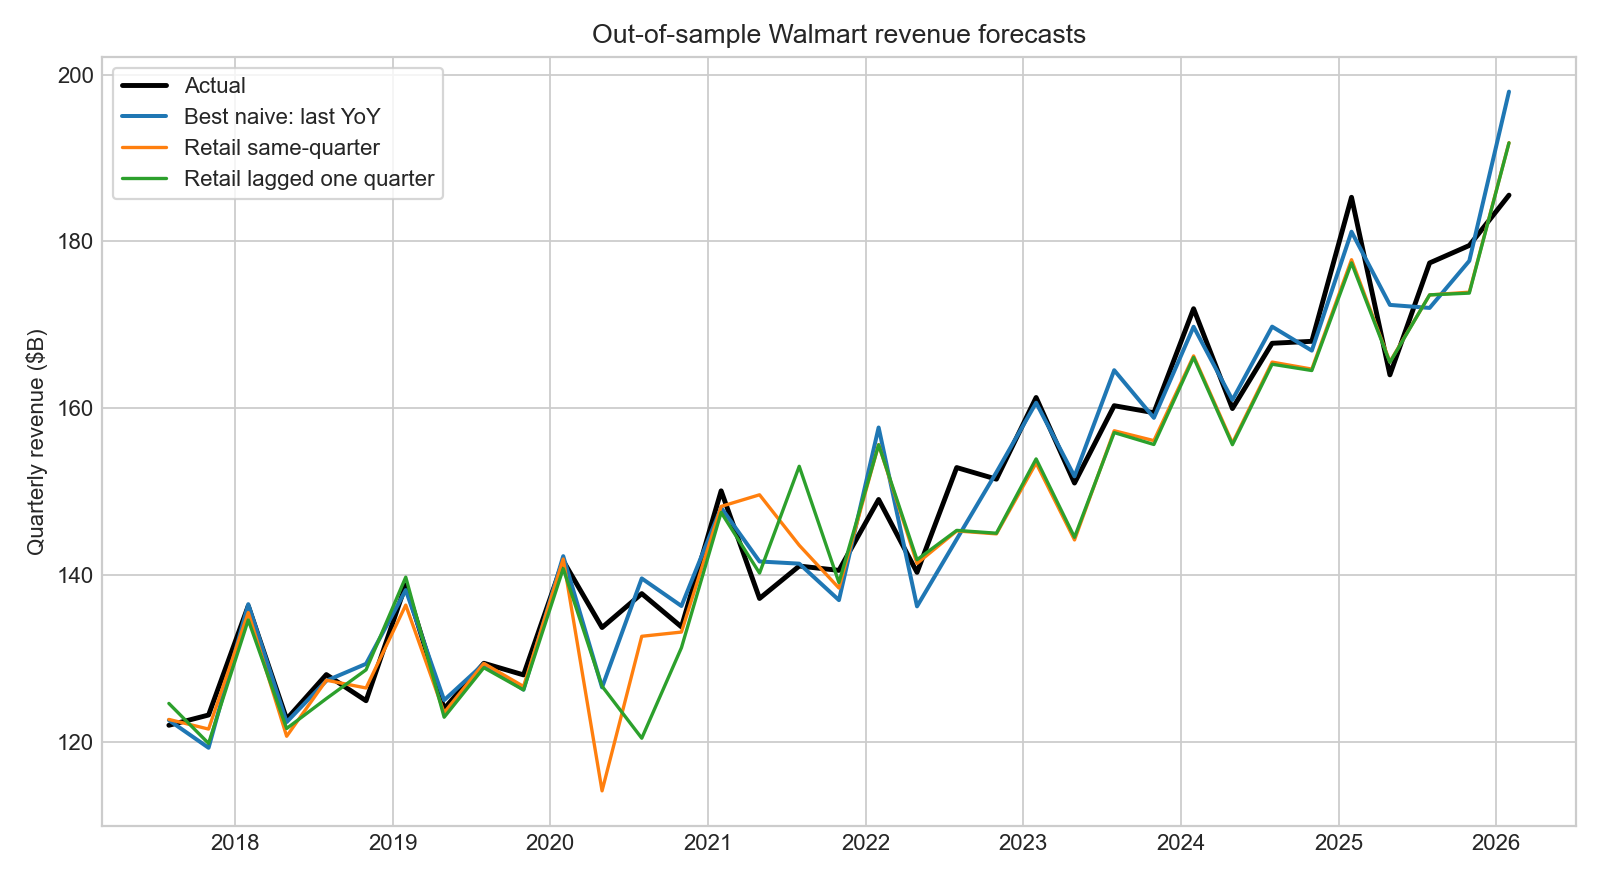

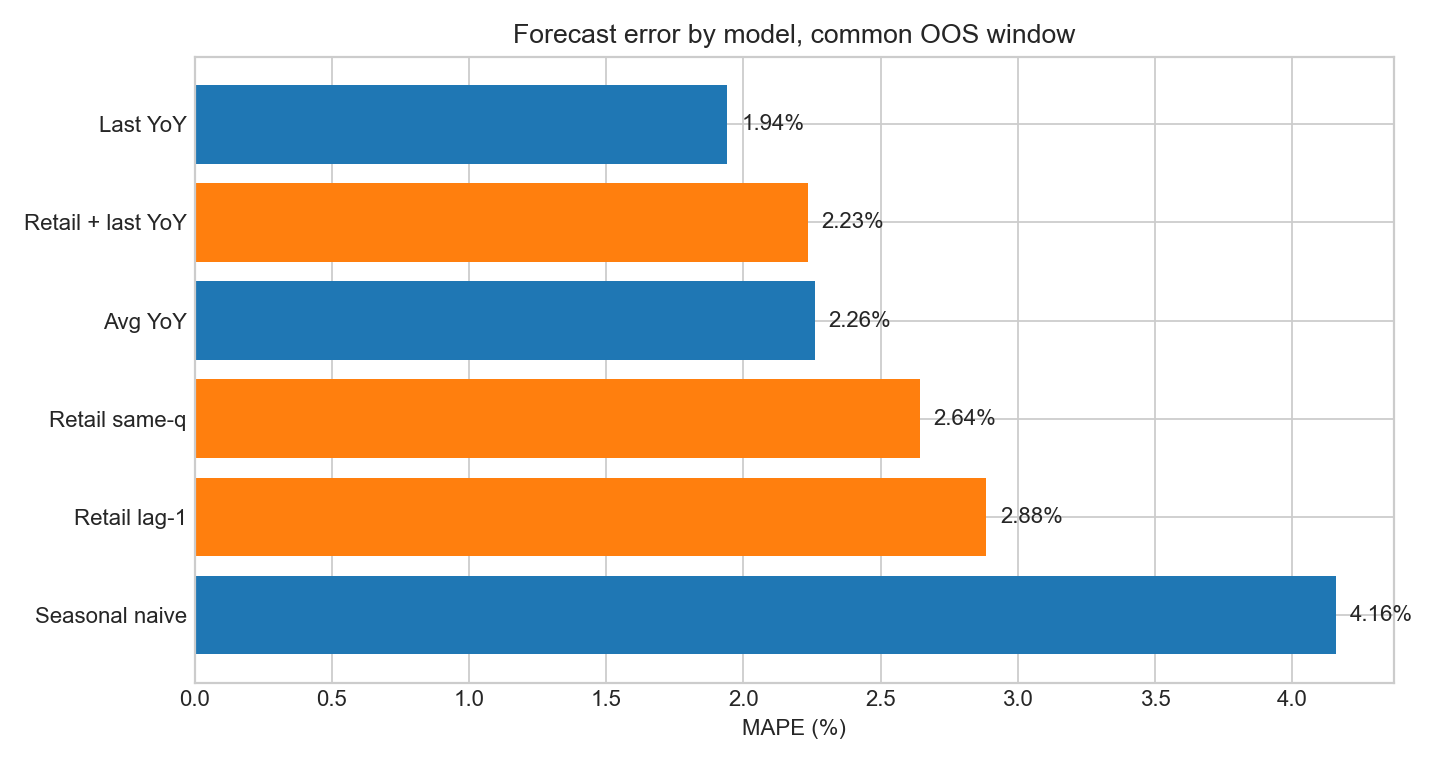

In [10]:
for style_name in ["seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"]:
    try:
        plt.style.use(style_name)
        break
    except OSError:
        continue

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_frame = common_preds.copy()
ax.plot(plot_frame["date"], plot_frame["actual"] / 1e9, color="black", linewidth=2.2, label="Actual")
ax.plot(plot_frame["date"], plot_frame["last_yoy"] / 1e9, color="#1f77b4", linewidth=1.8, label="Best naive: last YoY")
ax.plot(plot_frame["date"], plot_frame["retail_same_q"] / 1e9, color="#ff7f0e", linewidth=1.5, label="Retail same-quarter")
ax.plot(plot_frame["date"], plot_frame["retail_lag1"] / 1e9, color="#2ca02c", linewidth=1.5, label="Retail lagged one quarter")
ax.set_title("Out-of-sample Walmart revenue forecasts")
ax.set_ylabel("Quarterly revenue ($B)")
ax.set_xlabel("")
ax.legend(loc="upper left", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "forecast_comparison.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_metrics = metrics.copy()
labels = {
    "last_yoy": "Last YoY",
    "retail_lag1_plus_last_yoy": "Retail + last YoY",
    "historical_avg_yoy": "Avg YoY",
    "retail_same_q": "Retail same-q",
    "retail_lag1": "Retail lag-1",
    "seasonal_naive": "Seasonal naive",
}
plot_metrics["label"] = plot_metrics["model"].map(labels)
colors = ["#1f77b4" if m in ["last_yoy", "historical_avg_yoy", "seasonal_naive"] else "#ff7f0e" for m in plot_metrics["model"]]
ax.barh(plot_metrics["label"], 100 * plot_metrics["MAPE"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("MAPE (%)")
ax.set_title("Forecast error by model, common OOS window")
for i, value in enumerate(100 * plot_metrics["MAPE"]):
    ax.text(value + 0.05, i, f"{value:.2f}%", va="center")
fig.tight_layout()
fig.savefig(FIG_DIR / "mape_comparison.png", dpi=160)
plt.show()


## 10. Bottom line

On this data, the FRED retail-sales signal clears the very low bar of beating "same quarter last year," but it does not beat a stronger naive baseline that carries forward Walmart's latest observed YoY growth. The strict leading version, using one-quarter-lagged retail sales, is worse than both `last_yoy` and `historical_avg_yoy`.

That makes the recommendation a cautious "no" for using this FRED series as a standalone leading indicator of Walmart revenue. The signal is not useless; it sometimes wins quarter by quarter. But it does not produce a stable, economically meaningful improvement versus Walmart's own recent trend.

Evidence that would change my mind: a real-time data test with vintage FRED releases, clearly available-before-report timing, at least a 10% MAPE improvement versus `last_yoy`, and a positive contribution from retail sales across non-pandemic periods or comparable retailers.
